# Random Forest — Bagging of Trees to Reduce Variance

**What you'll learn:** Why single decision trees overfit, how bagging tames variance through averaging, and how Random Forests add a second layer of randomness to make the ensemble even better.

**Prerequisites:** Python, NumPy basics, intuition about decision trees.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
import ipywidgets as widgets
from IPython.display import display

rng = np.random.default_rng(42)

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#f8f8f8",
    "axes.grid":         True,
    "grid.color":        "white",
    "grid.linewidth":    1.2,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "sans-serif",
})

---
## 1 · The Variance Problem

Every supervised learning model makes errors that can be decomposed into **bias** and **variance**:

$$\text{Expected Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}$$

- **Bias** — systematic wrong assumptions in the model (e.g., a line fitting a curve).
- **Variance** — sensitivity to fluctuations in the training set. A high-variance model memorises training data and fails on new data.

Decision trees grown to full depth have **low bias** (they can fit any boundary) but **high variance** (tiny changes in data → wildly different trees).

> **Key insight:** If you average many independent, unbiased estimators, their variance drops. For $B$ trees each with variance $\sigma^2$, the variance of the average is $\sigma^2 / B$. That's the promise of bagging.

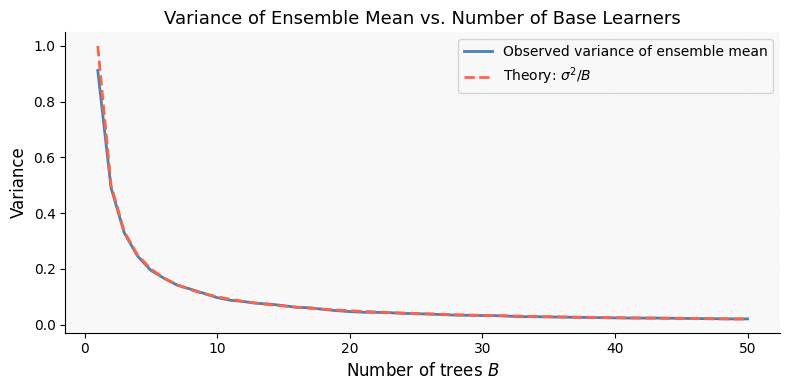

Variance with 1 tree : 0.912
Variance with 50 trees: 0.021


In [2]:
# --- Visualise variance reduction by averaging ---
# Simulate noisy estimates of a true value mu=0, each with variance sigma^2
mu, sigma = 0.0, 1.0
n_trials, max_B = 500, 50

estimates = rng.normal(mu, sigma, size=(n_trials, max_B))  # each row = one "experiment"

# Variance of ensemble mean as B grows
B_vals = np.arange(1, max_B + 1)
var_of_mean = [estimates[:, :b].mean(axis=1).var() for b in B_vals]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(B_vals, var_of_mean, color="steelblue", lw=2, label="Observed variance of ensemble mean")
ax.plot(B_vals, sigma**2 / B_vals, color="tomato", lw=2, ls="--", label=r"Theory: $\sigma^2 / B$")
ax.set_xlabel("Number of trees $B$", fontsize=12)
ax.set_ylabel("Variance", fontsize=12)
ax.set_title("Variance of Ensemble Mean vs. Number of Base Learners", fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Variance with 1 tree : {var_of_mean[0]:.3f}")
print(f"Variance with 50 trees: {var_of_mean[-1]:.3f}")

---
## 2 · Mathematical Foundation

### 2a — Bagging (Bootstrap AGGregatING)

Given a training set $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^{n}$, bagging creates $B$ bootstrapped datasets:

$$\mathcal{D}^{(b)} = \text{sample with replacement from } \mathcal{D}, \; |\mathcal{D}^{(b)}| = n$$

Each bootstrap sample contains ~63.2% unique examples (since each draw has $1/n$ chance of being any particular point, so after $n$ draws the probability of *not* being drawn is $(1-1/n)^n \to e^{-1} \approx 0.368$).

A tree $T_b$ is fitted on $\mathcal{D}^{(b)}$, and predictions are aggregated:

$$\hat{y} = \begin{cases} \text{majority vote}\{T_b(\mathbf{x})\}_{b=1}^B & \text{classification} \\ \frac{1}{B}\sum_{b=1}^B T_b(\mathbf{x}) & \text{regression} \end{cases}$$

### 2b — Why Averaging Reduces Variance

If trees have pairwise correlation $\rho$ and individual variance $\sigma^2$:

$$\text{Var}\!\left(\frac{1}{B}\sum_{b=1}^B T_b\right) = \rho\,\sigma^2 + \frac{1-\rho}{B}\sigma^2$$

As $B \to \infty$, the second term vanishes. What remains is $\rho\,\sigma^2$ — the **floor set by tree correlation**.

| Symbol | Meaning |
|--------|--------|
| $B$ | Number of trees |
| $\sigma^2$ | Variance of a single tree |
| $\rho$ | Average pairwise correlation between trees |
| $\mathcal{D}^{(b)}$ | $b$-th bootstrap sample |
| $T_b$ | Tree trained on $\mathcal{D}^{(b)}$ |
| $m$ | Number of features considered at each split |

### 2c — The Random Forest Trick

Standard bagging still produces correlated trees because all trees compete for the same dominant features. Random Forest breaks this by restricting each split to a **random subset of $m$ features**:

$$m \approx \sqrt{p} \text{ (classification)}, \quad m \approx p/3 \text{ (regression)}$$

where $p$ is the total number of features. This *decorrelates* the trees, shrinking $\rho$ and further reducing ensemble variance.

> **Key insight:** Random Forests reduce variance along two axes: bootstrapping (different data) and feature subsampling (different splits). The ensemble error floor $\rho\,\sigma^2$ decreases as trees become more independent.

---
## 3 · Dataset

We'll use a **2D moons** classification problem — two interleaved half-circles. It's non-linear enough that shallow models fail, but simple enough to visualise decision boundaries clearly.

In [3]:
def make_moons(n=300, noise=0.25, seed=42):
    rng_local = np.random.default_rng(seed)
    half = n // 2
    theta1 = rng_local.uniform(0, np.pi, half)
    theta2 = rng_local.uniform(0, np.pi, n - half)
    X1 = np.c_[np.cos(theta1), np.sin(theta1)]
    X2 = np.c_[1 - np.cos(theta2), 1 - np.sin(theta2) - 0.5]
    X = np.vstack([X1, X2]) + rng_local.normal(0, noise, (n, 2))
    y = np.array([0] * half + [1] * (n - half))
    idx = rng_local.permutation(n)
    return X[idx], y[idx]

X, y = make_moons(n=400, noise=0.28)

# 80/20 train-test split
split = int(0.8 * len(y))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Training samples: {len(y_train)} | Test samples: {len(y_test)}")

Training samples: 320 | Test samples: 80


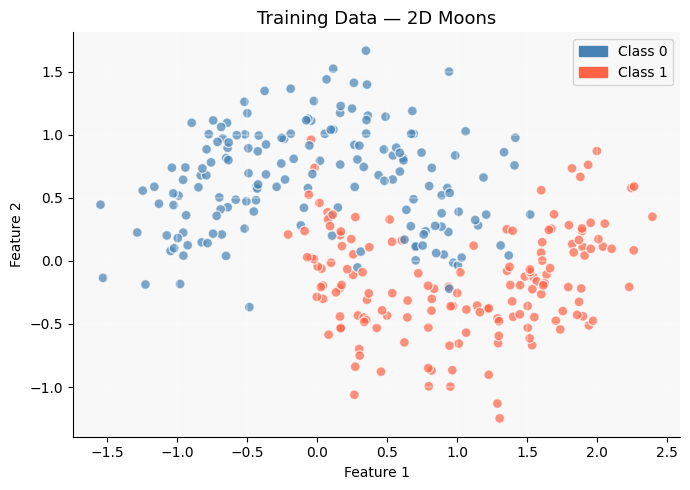

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = np.where(y_train == 0, "steelblue", "tomato")
ax.scatter(X_train[:, 0], X_train[:, 1], c=colors, alpha=0.7, edgecolors="white", s=50)
patch0 = mpatches.Patch(color="steelblue", label="Class 0")
patch1 = mpatches.Patch(color="tomato", label="Class 1")
ax.legend(handles=[patch0, patch1])
ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")
ax.set_title("Training Data — 2D Moons", fontsize=13)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4 · Bootstrap Sampling — A Closer Look

Before building trees, let's make bootstrap sampling concrete and verify the ~63.2% unique-sample claim.

Mean fraction of unique samples in bootstrap: 0.6316
Theory (1 - e⁻¹)                           : 0.6321


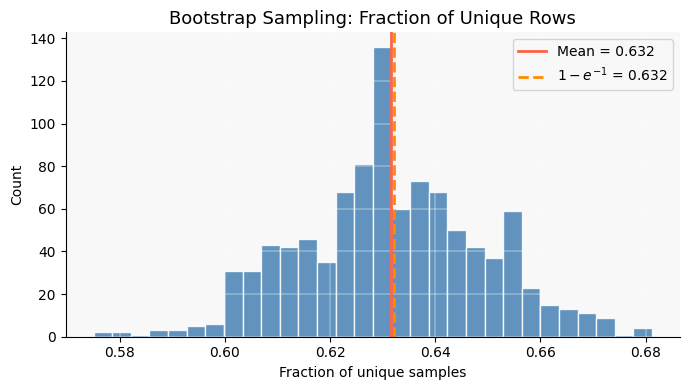

In [5]:
def bootstrap_sample(X, y, rng_state):
    """Sample n rows with replacement."""
    n = len(y)
    idx = rng_state.integers(0, n, size=n)
    oob_mask = np.ones(n, dtype=bool)
    oob_mask[idx] = False          # out-of-bag = rows NOT drawn
    return X[idx], y[idx], oob_mask

# Verify ~63.2% unique samples
n = len(y_train)
trials = 1000
unique_fracs = []
for _ in range(trials):
    idx = rng.integers(0, n, size=n)
    unique_fracs.append(len(np.unique(idx)) / n)

print(f"Mean fraction of unique samples in bootstrap: {np.mean(unique_fracs):.4f}")
print(f"Theory (1 - e⁻¹)                           : {1 - np.exp(-1):.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(unique_fracs, bins=30, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(np.mean(unique_fracs), color="tomato", lw=2, label=f"Mean = {np.mean(unique_fracs):.3f}")
ax.axvline(1 - np.exp(-1), color="darkorange", lw=2, ls="--", label=r"$1-e^{-1}$ = 0.632")
ax.set_xlabel("Fraction of unique samples"); ax.set_ylabel("Count")
ax.set_title("Bootstrap Sampling: Fraction of Unique Rows", fontsize=13)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5 · Decision Tree from Scratch

Random Forest's base learner is the CART decision tree. Let's build one.

### Splitting criterion — Gini Impurity

At each node we pick the feature $j$ and threshold $t$ that minimise the **weighted Gini impurity** of the two children:

$$\text{Gini}(S) = 1 - \sum_{k} p_k^2$$

where $p_k$ is the fraction of class $k$ in set $S$. The split quality is:

$$\Delta\text{Gini} = \text{Gini}(S) - \frac{|S_L|}{|S|}\text{Gini}(S_L) - \frac{|S_R|}{|S|}\text{Gini}(S_R)$$

We choose $(j^*, t^*)$ that maximise $\Delta\text{Gini}$.

> **Key insight:** Gini impurity measures *disorder* — a node where all labels match has Gini = 0 (pure). We greedily reduce disorder at each split.

In [6]:
def gini(y):
    if len(y) == 0:
        return 0.0
    counts = np.bincount(y)
    probs = counts / counts.sum()
    return 1.0 - np.sum(probs ** 2)

def best_split(X, y, feature_indices):
    """Find the best (feature, threshold) pair among the given feature indices."""
    best_gain, best_feat, best_thresh = -1.0, None, None
    parent_gini = gini(y)
    n = len(y)

    for feat in feature_indices:
        thresholds = np.unique(X[:, feat])
        for t in thresholds:
            left  = y[X[:, feat] <= t]
            right = y[X[:, feat] >  t]
            if len(left) == 0 or len(right) == 0:
                continue
            gain = parent_gini - (len(left)/n)*gini(left) - (len(right)/n)*gini(right)
            if gain > best_gain:
                best_gain, best_feat, best_thresh = gain, feat, t

    return best_feat, best_thresh

class Node:
    __slots__ = ("feat", "thresh", "left", "right", "label")
    def __init__(self, feat=None, thresh=None, left=None, right=None, label=None):
        self.feat, self.thresh = feat, thresh
        self.left, self.right = left, right
        self.label = label   # set only in leaf nodes

In [7]:
class DecisionTree:
    def __init__(self, max_depth=None, max_features=None, rng_state=None):
        self.max_depth    = max_depth
        self.max_features = max_features   # None → use all features (bagging); int → RF trick
        self.rng          = rng_state or np.random.default_rng()
        self.root         = None
        self.n_features_  = None

    def fit(self, X, y):
        self.n_features_ = X.shape[1]
        self.root = self._grow(X, y, depth=0)

    def _grow(self, X, y, depth):
        # Stopping conditions
        if len(np.unique(y)) == 1 or (self.max_depth is not None and depth >= self.max_depth):
            return Node(label=Counter(y).most_common(1)[0][0])

        # Random feature subset (the RF trick)
        p = self.n_features_
        m = self.max_features if self.max_features else p
        feat_idx = self.rng.choice(p, size=min(m, p), replace=False)

        feat, thresh = best_split(X, y, feat_idx)
        if feat is None:   # no useful split
            return Node(label=Counter(y).most_common(1)[0][0])

        mask = X[:, feat] <= thresh
        left  = self._grow(X[mask],  y[mask],  depth + 1)
        right = self._grow(X[~mask], y[~mask], depth + 1)
        return Node(feat=feat, thresh=thresh, left=left, right=right)

    def predict_one(self, x):
        node = self.root
        while node.label is None:
            node = node.left if x[node.feat] <= node.thresh else node.right
        return node.label

    def predict(self, X):
        return np.array([self.predict_one(x) for x in X])

---
## 6 · Random Forest from Scratch

The Random Forest algorithm is elegantly simple given the pieces above:

1. For each tree $b = 1, \ldots, B$:
   - Draw bootstrap sample $\mathcal{D}^{(b)}$
   - Grow `DecisionTree` with `max_features = m` on $\mathcal{D}^{(b)}$
2. Predict by majority vote across all $B$ trees.

The **out-of-bag (OOB) error** is a free validation estimate: for each training point $i$, predict using only the trees for which $i$ was *not* in the bootstrap sample.

In [8]:
class RandomForest:
    def __init__(self, n_estimators=100, max_depth=None, max_features="sqrt", seed=42):
        self.n_estimators = n_estimators
        self.max_depth    = max_depth
        self.max_features = max_features  # "sqrt", "log2", or int
        self.seed         = seed
        self.trees_       = []
        self.oob_masks_   = []
        self.oob_error_history_ = []

    def _resolve_max_features(self, p):
        if self.max_features == "sqrt":  return max(1, int(np.sqrt(p)))
        if self.max_features == "log2":  return max(1, int(np.log2(p)))
        if self.max_features is None:    return p
        return int(self.max_features)

    def fit(self, X, y):
        rng_master = np.random.default_rng(self.seed)
        n, p = X.shape
        m = self._resolve_max_features(p)
        self.trees_ = []
        self.oob_masks_ = []

        # OOB accumulator: rows=samples, cols=trees (NaN = in-bag)
        oob_preds = np.full((n, self.n_estimators), np.nan)

        for b in range(self.n_estimators):
            rng_b = np.random.default_rng(rng_master.integers(1 << 31))
            Xb, yb, oob_mask = bootstrap_sample(X, y, rng_b)

            tree = DecisionTree(max_depth=self.max_depth, max_features=m,
                                rng_state=np.random.default_rng(rng_master.integers(1 << 31)))
            tree.fit(Xb, yb)
            self.trees_.append(tree)
            self.oob_masks_.append(oob_mask)

            # Fill OOB predictions for samples not in this bootstrap
            if oob_mask.any():
                oob_preds[oob_mask, b] = tree.predict(X[oob_mask])

            # Cumulative OOB error after b+1 trees
            valid = ~np.all(np.isnan(oob_preds[:, :b+1]), axis=1)
            if valid.sum() > 0:
                votes = np.nanmean(oob_preds[valid, :b+1], axis=1).round().astype(int)
                self.oob_error_history_.append(np.mean(votes != y[valid]))
            else:
                self.oob_error_history_.append(np.nan)

        return self

    def predict_proba(self, X):
        """Return fraction of trees voting for class 1."""
        votes = np.array([t.predict(X) for t in self.trees_])  # (B, n)
        return votes.mean(axis=0)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

---
## 7 · Training and Evaluation

In [9]:
# Single full-depth tree (high variance baseline)
single_tree = DecisionTree(max_depth=None, max_features=None,
                           rng_state=np.random.default_rng(0))
single_tree.fit(X_train, y_train)
single_acc  = np.mean(single_tree.predict(X_test) == y_test)

# Random Forest
rf = RandomForest(n_estimators=100, max_depth=None, max_features="sqrt", seed=42)
rf.fit(X_train, y_train)
rf_acc = rf.score(X_test, y_test)

print(f"Single tree  accuracy : {single_acc:.3f}")
print(f"Random Forest accuracy: {rf_acc:.3f}")
print(f"OOB error (final)     : {rf.oob_error_history_[-1]:.3f}")

Single tree  accuracy : 0.887
Random Forest accuracy: 0.887
OOB error (final)     : 0.075


---
## 8 · Decision Boundary: Single Tree vs Random Forest

The most vivid illustration of variance reduction — the single tree's boundary is jagged and brittle while the forest's is smoother and more generalizable.

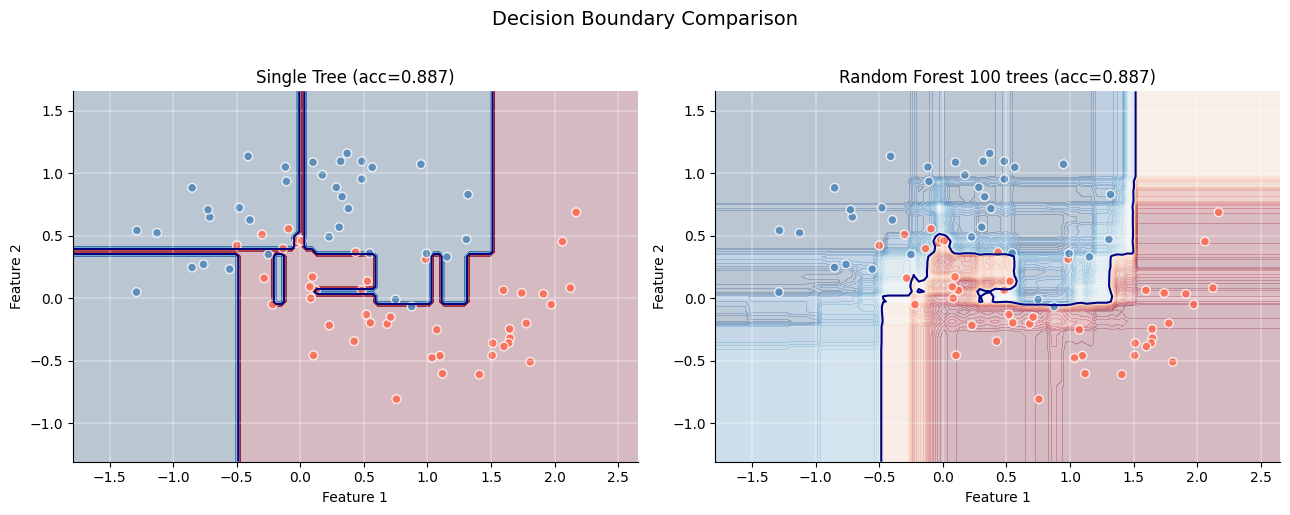

In [10]:
def plot_boundary(ax, model, X, y, title, use_proba=False):
    h = 0.04
    x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x1_min, x1_max, h),
                         np.arange(x2_min, x2_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]

    if use_proba:
        Z = model.predict_proba(grid).reshape(xx.shape)
    else:
        Z = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap="RdBu_r", levels=50)
    ax.contour(xx, yy, Z, levels=[0.5], colors="navy", linewidths=1.5)
    colors = np.where(y == 0, "steelblue", "tomato")
    ax.scatter(X[:, 0], X[:, 1], c=colors, edgecolors="white", s=40, alpha=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")
    ax.grid(alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_boundary(axes[0], single_tree, X_test, y_test,
              f"Single Tree (acc={single_acc:.3f})", use_proba=False)
plot_boundary(axes[1], rf, X_test, y_test,
              f"Random Forest 100 trees (acc={rf_acc:.3f})", use_proba=True)
plt.suptitle("Decision Boundary Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 9 · Variance Reduction Demonstrated

To make the variance reduction *measurable*, we train many individual trees on different bootstrap samples and compare their prediction spread to the forest's. We'll use a 1D regression-style setup to make it visually crisp.

We also plot the **OOB error** converging as more trees are added — this gives us a validation estimate without a held-out set.

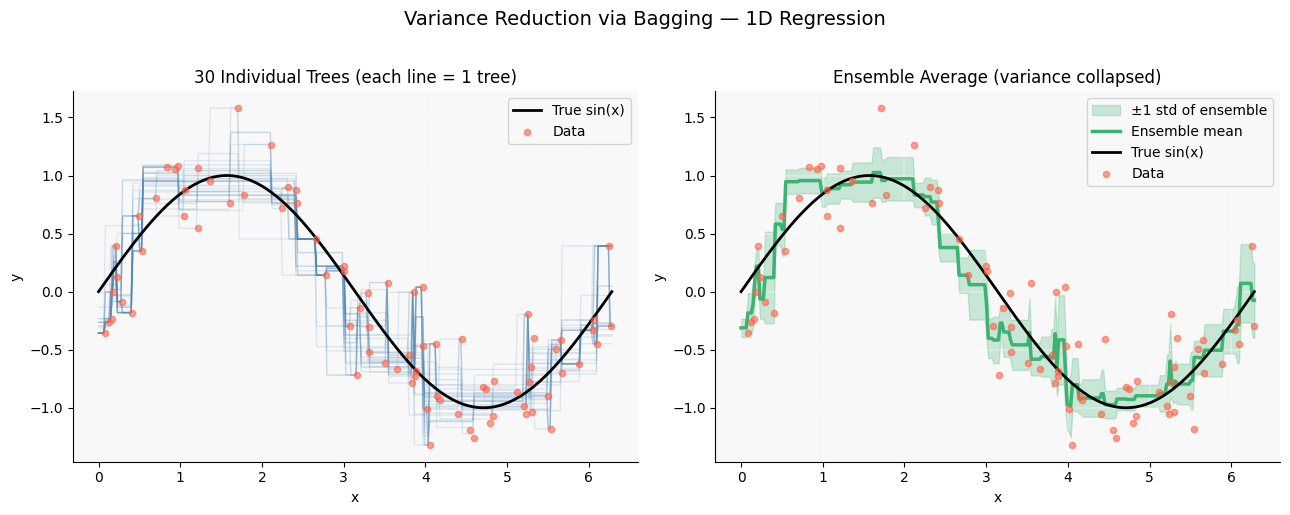

Mean std (individual trees): 0.181
Mean std (ensemble)        : 0.181


In [11]:
# 1D noisy sine regression to show variance spread
n_pts = 80
x1d = rng.uniform(0, 2 * np.pi, n_pts)
y1d = np.sin(x1d) + rng.normal(0, 0.3, n_pts)

x_plot = np.linspace(0, 2 * np.pi, 300).reshape(-1, 1)
X1d_train = x1d.reshape(-1, 1)

# Adapt DecisionTree for regression (use mean at leaves)
class RegressionTree:
    def __init__(self, max_depth=5, rng_state=None):
        self.max_depth = max_depth
        self.rng       = rng_state or np.random.default_rng()
        self.root      = None

    def _mse_gain(self, y, left_mask):
        yl, yr = y[left_mask], y[~left_mask]
        if len(yl) == 0 or len(yr) == 0: return -np.inf
        n = len(y)
        return y.var() - (len(yl)/n)*yl.var() - (len(yr)/n)*yr.var()

    def _best_split_reg(self, X, y):
        best_gain, best_feat, best_thresh = -np.inf, None, None
        for feat in range(X.shape[1]):
            for t in np.unique(X[:, feat]):
                gain = self._mse_gain(y, X[:, feat] <= t)
                if gain > best_gain:
                    best_gain, best_feat, best_thresh = gain, feat, t
        return best_feat, best_thresh

    def _grow(self, X, y, depth):
        if depth >= self.max_depth or len(y) <= 2:
            return {"leaf": True, "val": y.mean()}
        feat, t = self._best_split_reg(X, y)
        if feat is None: return {"leaf": True, "val": y.mean()}
        mask = X[:, feat] <= t
        return {"leaf": False, "feat": feat, "thresh": t,
                "left": self._grow(X[mask], y[mask], depth+1),
                "right": self._grow(X[~mask], y[~mask], depth+1)}

    def fit(self, X, y):
        self.root = self._grow(X, y.astype(float), 0)

    def _pred_one(self, node, x):
        if node["leaf"]: return node["val"]
        return self._pred_one(node["left"] if x[node["feat"]] <= node["thresh"] else node["right"], x)

    def predict(self, X):
        return np.array([self._pred_one(self.root, x) for x in X])

B = 30
individual_preds = []
for b in range(B):
    idx = np.random.default_rng(b).integers(0, n_pts, n_pts)
    rt = RegressionTree(max_depth=5, rng_state=np.random.default_rng(b))
    rt.fit(X1d_train[idx], y1d[idx])
    individual_preds.append(rt.predict(x_plot))

individual_preds = np.array(individual_preds)  # (B, 300)
ensemble_pred    = individual_preds.mean(axis=0)
pred_std         = individual_preds.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for i, p in enumerate(individual_preds):
    ax.plot(x_plot.ravel(), p, color="steelblue", alpha=0.15, lw=1)
ax.plot(x_plot.ravel(), np.sin(x_plot.ravel()), color="black", lw=2, label="True sin(x)")
ax.scatter(x1d, y1d, color="tomato", s=20, zorder=5, alpha=0.6, label="Data")
ax.set_title(f"{B} Individual Trees (each line = 1 tree)", fontsize=12)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.fill_between(x_plot.ravel(), ensemble_pred - pred_std, ensemble_pred + pred_std,
                alpha=0.25, color="mediumseagreen", label="±1 std of ensemble")
ax.plot(x_plot.ravel(), ensemble_pred, color="mediumseagreen", lw=2.5, label="Ensemble mean")
ax.plot(x_plot.ravel(), np.sin(x_plot.ravel()), color="black", lw=2, label="True sin(x)")
ax.scatter(x1d, y1d, color="tomato", s=20, zorder=5, alpha=0.6, label="Data")
ax.set_title("Ensemble Average (variance collapsed)", fontsize=12)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Variance Reduction via Bagging — 1D Regression", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print(f"Mean std (individual trees): {np.mean([individual_preds[:, i].std() for i in range(len(x_plot))]):.3f}")
print(f"Mean std (ensemble)        : {pred_std.mean():.3f}")

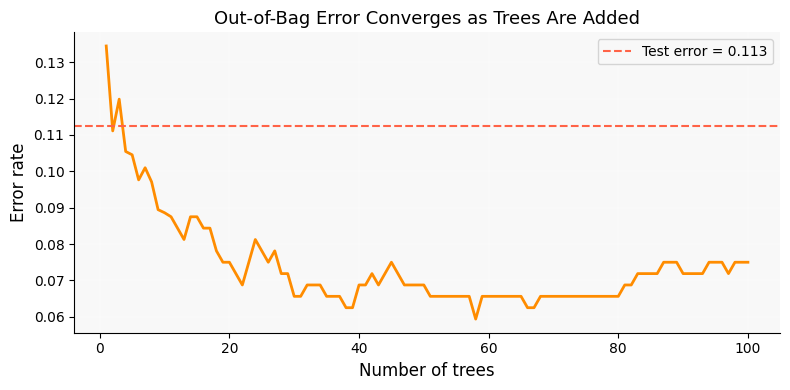

In [12]:
# OOB error converging with more trees
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(rf.oob_error_history_) + 1), rf.oob_error_history_,
        color="darkorange", lw=2)
ax.axhline(1 - rf_acc, color="tomato", ls="--", lw=1.5, label=f"Test error = {1-rf_acc:.3f}")
ax.set_xlabel("Number of trees", fontsize=12)
ax.set_ylabel("Error rate", fontsize=12)
ax.set_title("Out-of-Bag Error Converges as Trees Are Added", fontsize=13)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 10 · Feature Importance

Random Forests give a natural measure of feature importance: **mean decrease in Gini impurity** contributed by each feature across all splits in all trees.

$$\text{Importance}(j) = \frac{1}{B} \sum_{b=1}^{B} \sum_{\text{node } v \text{ splits on } j} \Delta\text{Gini}(v)$$

Normalised to sum to 1, this tells us which features the forest relies on most.

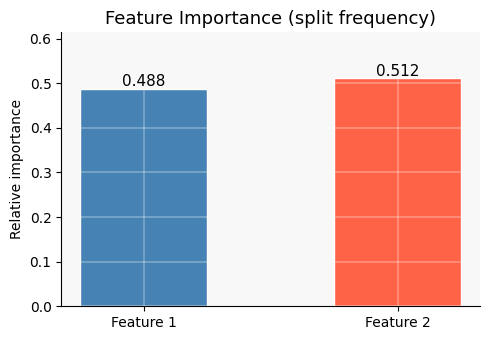

In [13]:
def tree_feature_importance(node, importances, n_features):
    """Recursively accumulate Gini gain at each split node."""
    if node is None or node.label is not None:   # leaf
        return
    importances[node.feat] += 1          # proxy: count splits per feature
    tree_feature_importance(node.left,  importances, n_features)
    tree_feature_importance(node.right, importances, n_features)

p = X_train.shape[1]
importances = np.zeros(p)
for tree in rf.trees_:
    tree_feature_importance(tree.root, importances, p)

importances /= importances.sum()
feat_names = ["Feature 1", "Feature 2"]

fig, ax = plt.subplots(figsize=(5, 3.5))
colors = ["steelblue", "tomato"]
ax.bar(feat_names, importances, color=colors, edgecolor="white", width=0.5)
for i, v in enumerate(importances):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=11)
ax.set_ylabel("Relative importance")
ax.set_title("Feature Importance (split frequency)", fontsize=13)
ax.set_ylim(0, max(importances) * 1.2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 11 · Effect of `n_estimators` — Interactive

Below you can slide the number of trees from 1 to 100 and watch the decision boundary evolve. With few trees the boundary is jagged; as trees accumulate it smooths out and stabilises.

> **Key insight:** Accuracy improves quickly at first and plateaus — there's diminishing return after ~30–50 trees for most problems. Adding more trees never *hurts* (unlike increasing depth), but it adds compute cost.

In [14]:
# Pre-compute mesh for speed
h = 0.05
x1_min, x1_max = X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5
x2_min, x2_max = X_test[:, 1].min() - 0.5, X_test[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x1_min, x1_max, h), np.arange(x2_min, x2_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]

# Pre-collect per-tree predictions on grid
tree_grid_preds = np.array([t.predict(grid) for t in rf.trees_])  # (100, n_grid)
test_labels     = np.array([t.predict(X_test) for t in rf.trees_])  # (100, n_test)

def show_n_trees(n_trees):
    proba = tree_grid_preds[:n_trees].mean(axis=0).reshape(xx.shape)
    acc   = np.mean(test_labels[:n_trees].mean(axis=0).round() == y_test)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.contourf(xx, yy, proba, alpha=0.3, cmap="RdBu_r", levels=50)
    ax.contour(xx, yy, proba, levels=[0.5], colors="navy", linewidths=1.5)
    clrs = np.where(y_test == 0, "steelblue", "tomato")
    ax.scatter(X_test[:, 0], X_test[:, 1], c=clrs, edgecolors="white", s=45, alpha=0.9)
    ax.set_title(f"n_estimators = {n_trees}  |  Test accuracy = {acc:.3f}", fontsize=13)
    ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

slider = widgets.IntSlider(value=1, min=1, max=100, step=1,
                           description="n_trees:",
                           style={"description_width": "initial"},
                           layout=widgets.Layout(width="500px"))
widgets.interact(show_n_trees, n_trees=slider);

interactive(children=(IntSlider(value=1, description='n_trees:', layout=Layout(width='500px'), min=1, style=Sl…

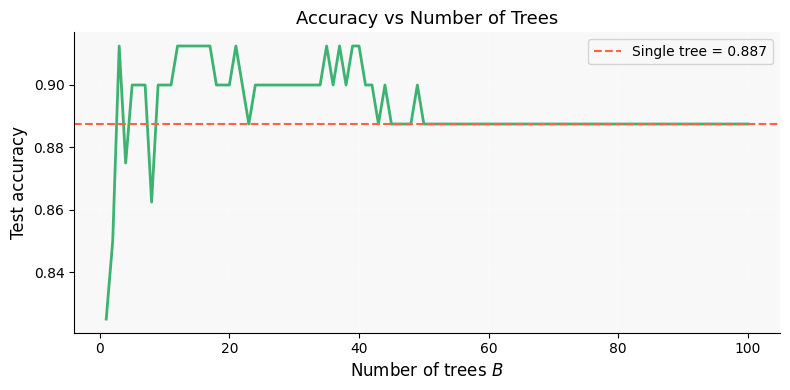

In [15]:
# Accuracy curve vs n_estimators (static version for non-interactive environments)
acc_curve = [np.mean(test_labels[:b+1].mean(axis=0).round() == y_test)
             for b in range(len(rf.trees_))]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(acc_curve) + 1), acc_curve, color="mediumseagreen", lw=2)
ax.axhline(single_acc, color="tomato", ls="--", lw=1.5, label=f"Single tree = {single_acc:.3f}")
ax.set_xlabel("Number of trees $B$", fontsize=12)
ax.set_ylabel("Test accuracy", fontsize=12)
ax.set_title("Accuracy vs Number of Trees", fontsize=13)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 12 · Summary

| Concept | Key Idea |
|---------|----------|
| Bias–Variance tradeoff | Full trees: low bias, high variance. Ensembles attack the variance side. |
| Bagging | Train $B$ trees on bootstrap samples, aggregate predictions |
| Bootstrap sample | Sample $n$ rows with replacement; ~63.2% unique per bag |
| Variance of ensemble | $\rho\sigma^2 + (1-\rho)\sigma^2/B$ — drops as $B$ grows |
| RF feature subsampling | At each split, consider only $m \approx \sqrt{p}$ random features |
| Effect of $m$ | Smaller $m$ → less correlated trees → lower $\rho$ → lower ensemble variance |
| OOB error | Free validation estimate using the ~36.8% samples excluded per tree |
| Feature importance | Accumulated Gini gain per feature across all splits in all trees |
| Increasing $B$ | Never hurts accuracy; plateaus quickly; adds compute cost |
| Gini impurity | $1 - \sum_k p_k^2$; measures disorder; minimised greedily at each split |